## **Problema Astrofísico propuesto**
Los astrónomos modernos no observan un solo objeto; apuntan sus telescopios a un “Campo Profundo” (un parche de cielo) y extraen todo lo que hay en él utilizando diferentes longitudes de onda.

Su misión como equipo es analizar el campo ecuatorial centrado en las coordenadas RA: 135.5, Dec: 0.5 (con un radio de 0.5 grados). Deben cartografiar esta región para separar las estrellas locales de nuestra galaxia, aislar las galaxias lejanas y descubrir cuásares enrojecidos por el polvo. Para lograrlo, deberán combinar astrometría, espectroscopía y fotometría óptica e infrarroja.

En este notebook se llevará a cabo un analisis cosmologico de la region del cielo propuesta. Para esto, se extraeran datos de espectrometría desde la base de datos de *SkyServer* con lo cual veremos la distribución de los objetos clasificados por SDSS dependiendo de su indice de color $(u - g)$ y su corrimiento al rojo por la expansión del Universo ($z$). 

A continuación se muestran el procedimiento detallado:



### **Se importan los modulos necesarios**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

## Descarga de datos desde SDSS
Se consulta la base de SDSS para obtener objetos cercanos y se guarda la tabla en datos.csv para su análisis posterior.

In [4]:
%%bash

# Este script de bash se encarga de extraer una tabla de skyserver mediante una consulta SQL
ADQL="SELECT s.class, s.z, p.u, p.g FROM SpecObjAll AS s INNER JOIN dbo.fGetNearbyObjAllEq(135.5, 0.5, 30) AS n ON s.bestObjID = n.objID INNER JOIN PhotoObjAll AS p ON s.bestObjID = p.objID
"
QUERY=$(echo $ADQL | ./crear_query)
ENDPOINT="http://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd="

URL=${ENDPOINT}${QUERY}

wget2 -q -O datos.csv $URL

wc -l datos.csv

301 datos.csv


## Carga inicial del dataset
Leemos el archivo CSV y revisamos las primeras filas para verificar que la tabla se haya importado correctamente.

In [5]:
df = pd.read_csv('datos.csv', skiprows=1,)
print(df.head())

df.describe()

    class         z         u         g
0     QSO  2.664498  21.54961  21.11090
1  GALAXY  0.417612  26.67809  20.95143
2  GALAXY  0.148813  20.86312  18.70774
3     QSO  0.484559  24.45637  21.75349
4  GALAXY  0.018491  16.81240  15.77329


,z,u,g
count,299.000000,299.000000,299.000000
mean,0.518767,22.017202,20.545664
std,0.792305,2.236638,1.935963
min,-0.000574,16.812400,15.773290
25%,0.012777,20.024025,18.903390
50%,0.299654,22.220260,20.842580
75%,0.559854,23.684085,22.140455
max,5.542272,27.284410,25.544310


## Objetivo del análisis
En esta parte se define la estrategia del trabajo: limpiar el dataset, calcular un indicador de color y visualizar la distribución por clase astronómica.

## Limpieza de datos
Se eliminan filas con valores faltantes y se descartan registros inválidos para preparar un dataset limpio.

In [6]:
# Limpieza de datos
df = df.dropna()
mascara = (df['z'] == -9999) | (df['u'] == -9999) | (df['g'] == -9999)
df_nuevo = df.drop(df[mascara].index, inplace=True)
df_nuevo = df.reset_index(drop=True)



## Cálculo del 'indice de color'
Se crea la columna indice color como la diferencia u - g, la cual ayuda a separar objetos por tipo.

In [7]:
# se define la columna color
df_nuevo['indice color'] = df_nuevo['u'] - df_nuevo['g']

df_nuevo.head()

,class,z,u,g,indice color
0,QSO,2.664498,21.54961,21.11090,0.43871
1,GALAXY,0.417612,26.67809,20.95143,5.72666
2,GALAXY,0.148813,20.86312,18.70774,2.15538
3,QSO,0.484559,24.45637,21.75349,2.70288
4,GALAXY,0.018491,16.81240,15.77329,1.03911


## Dispersión para todas las clases
Se grafica el corrimiento al rojo frente al índice de color para GALAXY, QSO y STAR en una misma figura.

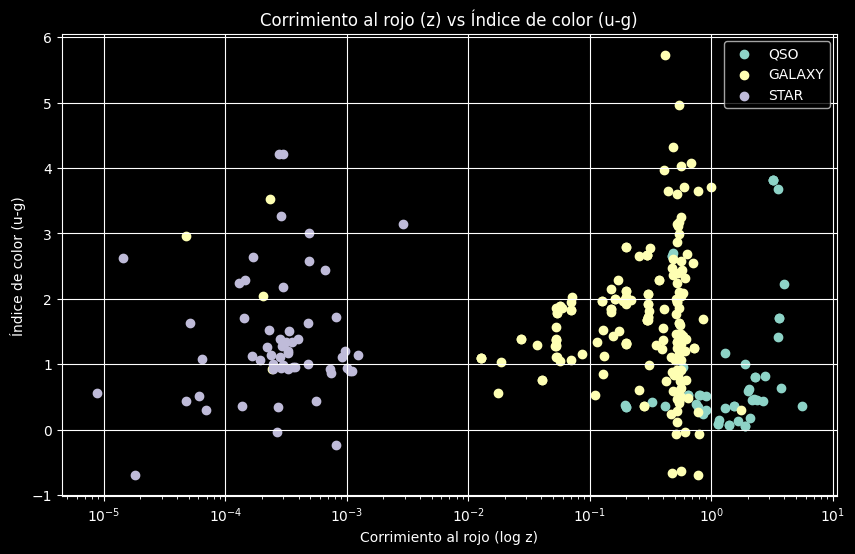

In [10]:
# Grafica de dispersión del corrimiento al rojo (z) vs el índice de color (u-g)
plt.figure(figsize=(10, 6))

# lo ponemos en apariencia oscura
plt.style.use('dark_background')

# separamos por clases (GALAXY, QSO, STAR)
for clase in df_nuevo['class'].unique():
    df_clase = df_nuevo[df_nuevo['class'] == clase]
    plt.scatter(df_clase['z'], df_clase['indice color'], alpha=1, marker='o', label=clase)


plt.title('Corrimiento al rojo (z) vs Índice de color (u-g)')
plt.xlabel('Corrimiento al rojo (log z)')
plt.xscale('log')
plt.ylabel('Índice de color (u-g)')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('imagenes_spec/corrimiento_color.png', dpi=300, bbox_inches='tight')
plt.show()


## Vista enfocada en estrellas
Se repite la visualización solo para objetos de tipo STAR para observar su comportamiento de forma más clara.

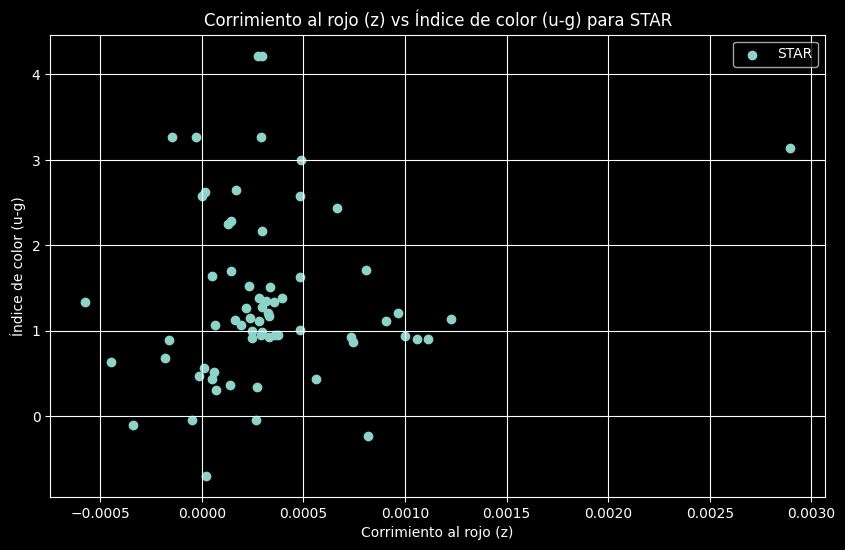

In [11]:
# Grafica de dispersión del corrimiento al rojo (z) vs el índice de color (u-g)
plt.figure(figsize=(10, 6))

# lo ponemos en apariencia oscura
plt.style.use('dark_background')

df_clase = df_nuevo[df_nuevo['class'] == 'STAR']

plt.scatter(df_clase['z'], df_clase['indice color'], alpha=1, marker='o', label='STAR')
plt.title('Corrimiento al rojo (z) vs Índice de color (u-g) para STAR')
plt.xlabel('Corrimiento al rojo (z)')
plt.ylabel('Índice de color (u-g)')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('imagenes_spec/corrimiento_color_star.png', dpi=300, bbox_inches='tight')
plt.show()